# Melbourne Housing Price Predictor

## Project Goal

This notebook builds an end-to-end machine learning workflow for forecasting Melbourne median house prices from the Victorian Property Sales Report (VPSR).

It is designed as a portfolio-ready project with:

- clear problem framing
- reusable data cleaning logic
- detailed exploratory analysis
- interpretable feature engineering
- model benchmarking across five regressors
- artifact export for deployment
- visual outputs suitable for GitHub presentation


## Notebook Roadmap

1. Load dependencies and configure paths
2. Clean the raw VPSR Excel files into a tidy quarterly dataset
3. Explore the data with descriptive statistics and visualizations
4. Build lag-based forecasting features
5. Train and compare regression models
6. Export artifacts for reuse and deployment
7. Predict future prices with a helper function
8. Provide an optional FastAPI deployment layer
9. Summarize the main findings and limitations


In [18]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path
from typing import Callable, Iterable, Literal

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

try:
    from fastapi import FastAPI, HTTPException
    from pydantic import BaseModel, Field
except ImportError:
    FastAPI = None
    HTTPException = None
    BaseModel = None
    Field = None

warnings.filterwarnings('ignore', message='X does not have valid feature names, but LGBMRegressor was fitted with feature names')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATASET_DIR = ROOT / 'dataset'
ARTIFACTS_DIR = ROOT / 'artifacts'
ASSETS_DIR = ROOT / 'assets'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', ROOT)
print('Dataset directory:', DATASET_DIR)
print('Artifacts directory:', ARTIFACTS_DIR)
print('Assets directory:', ASSETS_DIR)


def annotate_bars(ax, orientation: str = 'v', formatter: Callable[[float], str] | None = None, text_offset: float = 3.0) -> None:
    # Add explicit numeric labels to bar charts for easier interpretation in GitHub renders.
    if formatter is None:
        formatter = lambda value: f'{value:,.0f}'

    for patch in ax.patches:
        if orientation == 'v':
            value = patch.get_height()
            x = patch.get_x() + patch.get_width() / 2
            y = value
            ax.annotate(
                formatter(value),
                (x, y),
                ha='center',
                va='bottom',
                xytext=(0, text_offset),
                textcoords='offset points',
                fontsize=10,
            )
        else:
            value = patch.get_width()
            x = value
            y = patch.get_y() + patch.get_height() / 2
            ax.annotate(
                formatter(value),
                (x, y),
                ha='left',
                va='center',
                xytext=(text_offset, 0),
                textcoords='offset points',
                fontsize=10,
            )


def save_figure(name: str) -> None:
    # Save a static image so the README can showcase key visuals.
    plt.savefig(ASSETS_DIR / name, dpi=200, bbox_inches='tight')


Project root: E:\!Projects\Python\Melbourne Housing Price Predictor
Dataset directory: E:\!Projects\Python\Melbourne Housing Price Predictor\dataset
Artifacts directory: E:\!Projects\Python\Melbourne Housing Price Predictor\artifacts
Assets directory: E:\!Projects\Python\Melbourne Housing Price Predictor\assets


## Data Cleaning Functions

The VPSR source files use inconsistent multi-row headers, unnamed columns, and embedded year labels. The following helper functions convert those spreadsheets into a clean locality-quarter panel that can be analyzed and modeled.


In [19]:
QUARTER_NAME_TO_NUM = {
    'jan-mar': 1,
    'apr-jun': 2,
    'jul-sep': 3,
    'oct-dec': 4,
}

PRICE_EXCLUDE_KEYWORDS = ('sale', 'change', 'ytd', 'no.', 'no of', '%')
LOCALITY_KEYWORDS = ('locality', 'suburb')


def normalize_text(value: object) -> str:
    # Normalize case and whitespace to make header parsing more robust.
    if value is None:
        return ''
    text = str(value).strip().lower()
    return re.sub(r'\s+', ' ', text)


def parse_numeric(value: object) -> float | None:
    # Extract a float value from spreadsheet cells that may contain symbols or notes.
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    text = str(value).strip()
    if not text:
        return None
    cleaned = re.sub(r'[^0-9\.-]', '', text)
    if cleaned in {'', '-', '.', '-.'}:
        return None
    try:
        return float(cleaned)
    except ValueError:
        return None


def extract_year_from_series(values: Iterable[object]) -> int | None:
    # Some files store the year in the first rows below the header instead of in the header itself.
    for value in values:
        if value is None or (isinstance(value, float) and np.isnan(value)):
            continue
        match = re.search(r'(19|20)\d{2}', str(value))
        if match:
            return int(match.group(0))
    return None


def extract_quarter_and_year(raw_col_name: str, sample_values: pd.Series) -> tuple[int, int] | None:
    # Determine whether a column stores quarterly prices and recover its quarter-year pair.
    col = normalize_text(raw_col_name.replace('\n', ' '))
    if any(keyword in col for keyword in PRICE_EXCLUDE_KEYWORDS):
        return None

    quarter_num = None
    for q_name, q_num in QUARTER_NAME_TO_NUM.items():
        if q_name in col:
            quarter_num = q_num
            break

    if quarter_num is None:
        return None

    year_match = re.search(r'(19|20)\d{2}', col)
    year = int(year_match.group(0)) if year_match else extract_year_from_series(sample_values.head(5).tolist())
    if year is None:
        return None
    return quarter_num, year


def get_locality_column(df: pd.DataFrame) -> str:
    # Identify the suburb/locality column even when file schemas vary slightly.
    for col in df.columns:
        normalized = normalize_text(col)
        if any(keyword in normalized for keyword in LOCALITY_KEYWORDS):
            return col
    return df.columns[0]


def read_one_file(path: Path) -> pd.DataFrame:
    # Convert a single VPSR spreadsheet into tidy locality-quarter-price rows.
    df = pd.read_excel(path, sheet_name=0, dtype=object)
    if df.empty:
        return pd.DataFrame(columns=['locality', 'year', 'quarter', 'median_price', 'source_file'])

    locality_col = get_locality_column(df)
    working = df.copy()
    working[locality_col] = working[locality_col].astype(str).str.strip()

    records = []
    for col in working.columns:
        if col == locality_col:
            continue
        parsed = extract_quarter_and_year(str(col), working[col])
        if not parsed:
            continue

        quarter_num, year = parsed
        for _, row in working[[locality_col, col]].iterrows():
            locality = str(row[locality_col]).strip()
            if not locality or locality.lower() == 'nan':
                continue
            if re.search(r'^(total|grand total|median house prices)', locality.lower()):
                continue

            price = parse_numeric(row[col])
            if price is None or price <= 0:
                continue

            records.append(
                {
                    'locality': locality.upper(),
                    'year': int(year),
                    'quarter': int(quarter_num),
                    'median_price': float(price),
                    'source_file': path.name,
                }
            )

    return pd.DataFrame.from_records(records)


def load_and_clean_dataset(dataset_dir: str | Path) -> pd.DataFrame:
    # Merge all raw spreadsheets and deduplicate overlapping locality-quarter values.
    dataset_path = Path(dataset_dir)
    if not dataset_path.exists():
        raise FileNotFoundError(f'Dataset directory not found: {dataset_path}')

    files = sorted(dataset_path.glob('*.xls'))
    if not files:
        raise FileNotFoundError(f'No .xls files found in: {dataset_path}')

    all_parts = [read_one_file(path) for path in files]
    non_empty_parts = [part for part in all_parts if not part.empty]
    if not non_empty_parts:
        raise ValueError('No valid price data extracted from VPSR files.')

    df = pd.concat(non_empty_parts, ignore_index=True)
    deduped = (
        df.groupby(['locality', 'year', 'quarter'], as_index=False)['median_price']
        .mean()
        .sort_values(['locality', 'year', 'quarter'])
    )
    deduped['date'] = pd.PeriodIndex.from_fields(
        year=deduped['year'],
        quarter=deduped['quarter'],
        freq='Q',
    ).to_timestamp()
    return deduped


## Load the Dataset

We begin by consolidating all raw VPSR spreadsheets into a single long-format table.


In [20]:
clean_df = load_and_clean_dataset(DATASET_DIR)

print('Number of rows:', len(clean_df))
print('Number of localities:', clean_df['locality'].nunique())
print('Date range:', clean_df['date'].min().date(), 'to', clean_df['date'].max().date())

clean_df.head()


Number of rows: 7554
Number of localities: 777
Date range: 2023-01-01 to 2025-04-01


,locality,year,quarter,median_price,date
0,ABBOTSFORD,2023,1,"1,412,000.00",2023-01-01
1,ABBOTSFORD,2023,2,"1,005,000.00",2023-04-01
2,ABBOTSFORD,2023,3,"1,280,000.00",2023-07-01
3,ABBOTSFORD,2023,4,"1,283,800.00",2023-10-01
4,ABBOTSFORD,2024,1,"892,501.78",2024-01-01


## Dataset Overview

The cleaned dataset supports a broad suburb-level view of the Melbourne market. The first chart shows the distribution of available quarterly observations, and the second highlights the localities with the largest history depth.


In [21]:
overview_df = pd.DataFrame(
    {
        'Metric': [
            'Rows',
            'Unique localities',
            'Unique quarters',
            'Median price',
            'Minimum price',
            'Maximum price',
        ],
        'Value': [
            len(clean_df),
            clean_df['locality'].nunique(),
            clean_df[['year', 'quarter']].drop_duplicates().shape[0],
            clean_df['median_price'].median(),
            clean_df['median_price'].min(),
            clean_df['median_price'].max(),
        ],
    }
)
overview_df


,Metric,Value
0,Rows,"7,554.00"
1,Unique localities,777.00
2,Unique quarters,10.00
3,Median price,"735,500.00"
4,Minimum price,"68,000.00"
5,Maximum price,"7,240,000.00"


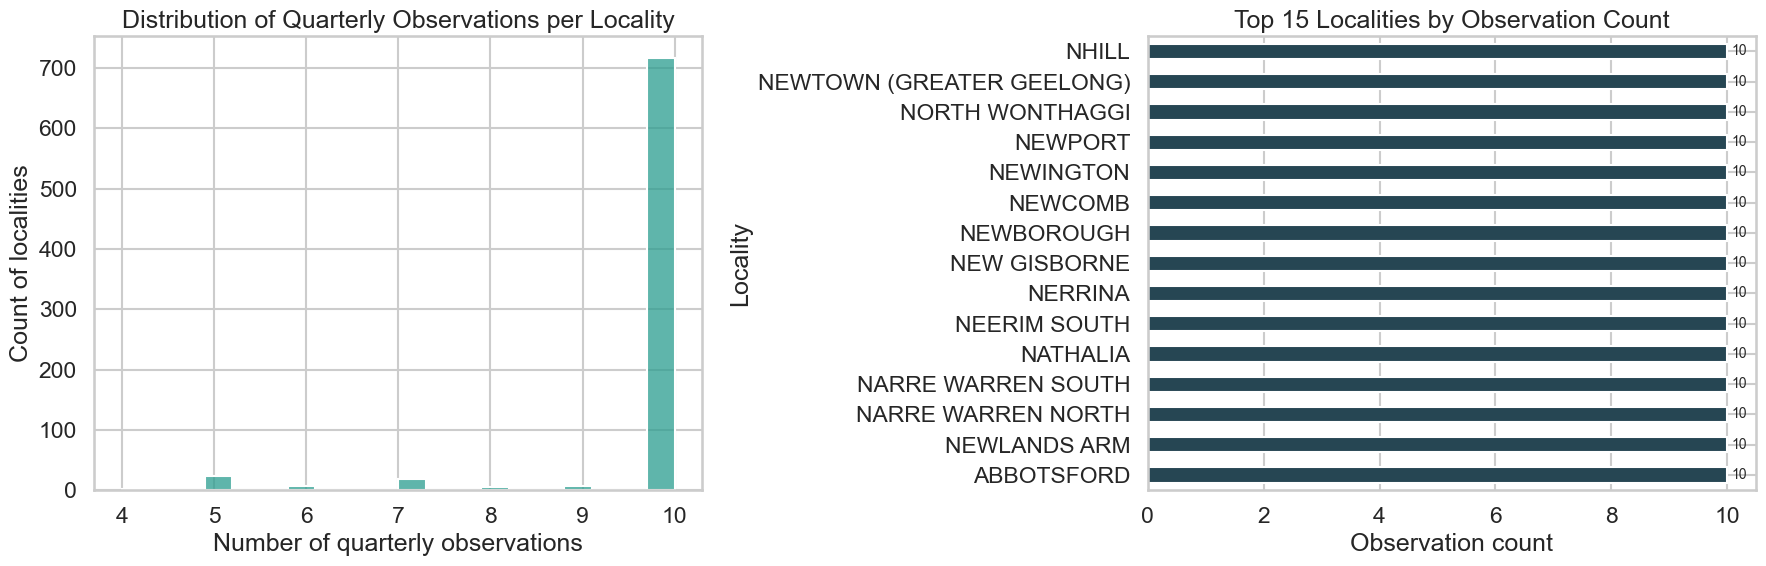

In [22]:
obs_per_locality = clean_df.groupby('locality').size().sort_values(ascending=False)

top_obs = obs_per_locality.head(15).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(obs_per_locality, bins=20, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribution of Quarterly Observations per Locality')
axes[0].set_xlabel('Number of quarterly observations')
axes[0].set_ylabel('Count of localities')

ax_obs = top_obs.plot(kind='barh', ax=axes[1], color='#264653')
axes[1].set_title('Top 15 Localities by Observation Count')
axes[1].set_xlabel('Observation count')
axes[1].set_ylabel('Locality')
annotate_bars(ax_obs, orientation='h', formatter=lambda value: f'{value:,.0f}')

plt.tight_layout()
save_figure('observation_coverage.png')
plt.show()


## Price Distribution

House prices are clearly right-skewed, which is common in real estate data. The histogram reveals the long upper tail, while the box plot highlights the spread and high-value outliers.


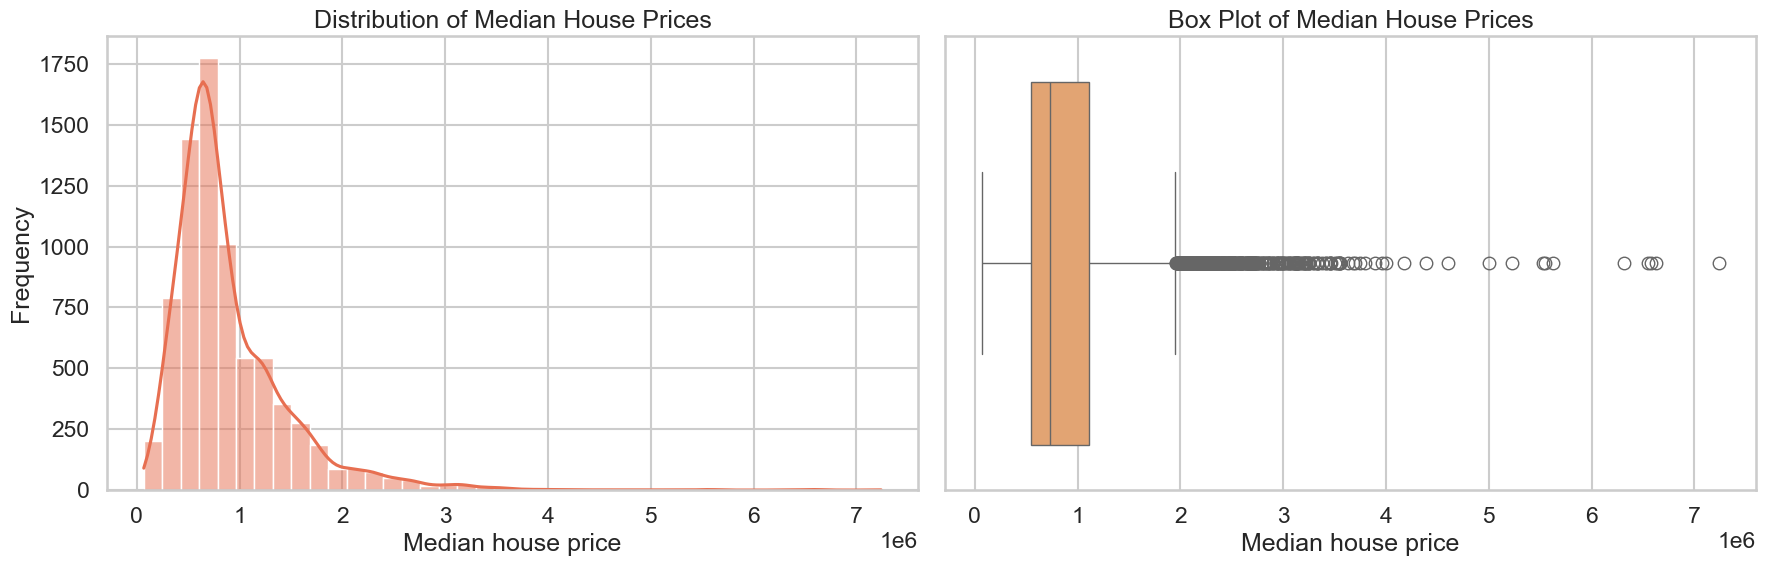

count       7,554.00
mean      898,339.83
std       573,428.30
min        68,000.00
10%       380,000.00
25%       549,250.00
50%       735,500.00
75%     1,110,000.00
90%     1,594,820.00
95%     1,999,512.50
max     7,240,000.00
Name: median_price, dtype: float64

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(clean_df['median_price'], bins=40, kde=True, ax=axes[0], color='#e76f51')
axes[0].set_title('Distribution of Median House Prices')
axes[0].set_xlabel('Median house price')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=clean_df['median_price'], ax=axes[1], color='#f4a261')
axes[1].set_title('Box Plot of Median House Prices')
axes[1].set_xlabel('Median house price')

plt.tight_layout()
save_figure('price_distribution.png')
plt.show()

clean_df['median_price'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])


## Market Trend Over Time

The chart below tracks the average locality-level median price by quarter. This provides a simple top-down view of how the market evolved across the available time window.


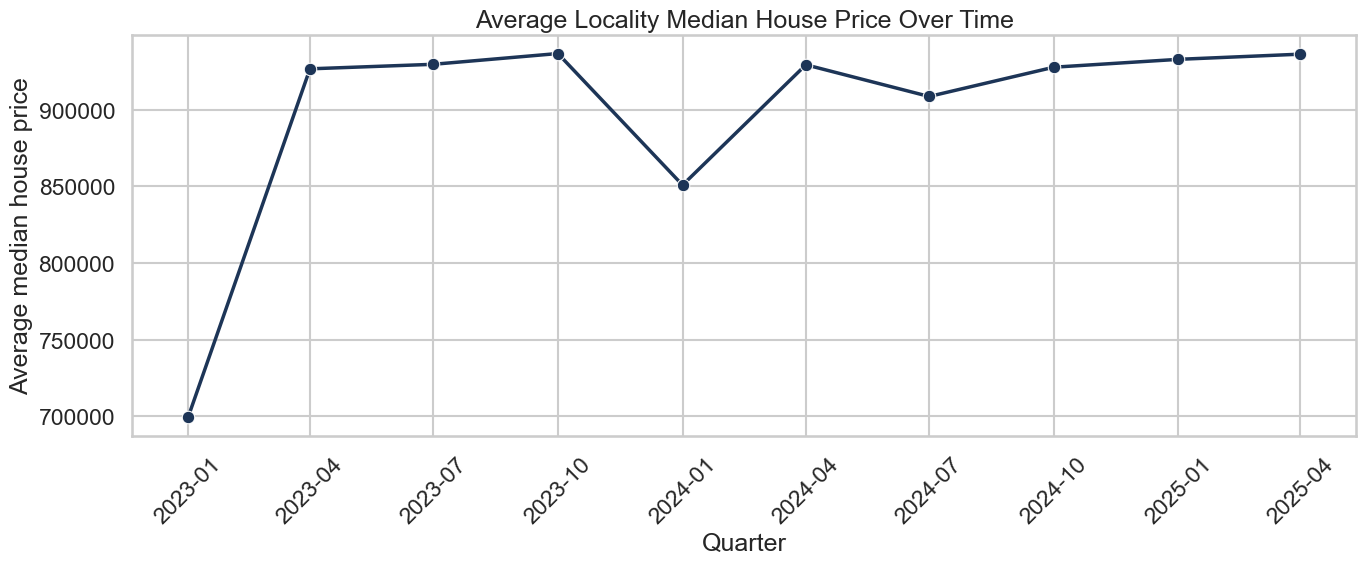

,date,median_price
0,2023-01-01,"699,125.05"
1,2023-04-01,"926,860.23"
2,2023-07-01,"929,817.26"
3,2023-10-01,"936,855.02"
4,2024-01-01,"850,928.58"
5,2024-04-01,"929,506.60"
6,2024-07-01,"908,797.02"
7,2024-10-01,"927,920.85"
8,2025-01-01,"933,064.67"
9,2025-04-01,"936,440.11"


In [24]:
market_trend = clean_df.groupby('date', as_index=False)['median_price'].mean()

plt.figure(figsize=(14, 6))
sns.lineplot(data=market_trend, x='date', y='median_price', marker='o', linewidth=2.5, color='#1d3557')
plt.title('Average Locality Median House Price Over Time')
plt.xlabel('Quarter')
plt.ylabel('Average median house price')
plt.xticks(rotation=45)
plt.tight_layout()
save_figure('market_trend.png')
plt.show()

market_trend


## Latest Market Snapshot

This chart shows the most expensive localities in the latest available quarter. Numeric bar labels make it easier to compare suburbs directly.


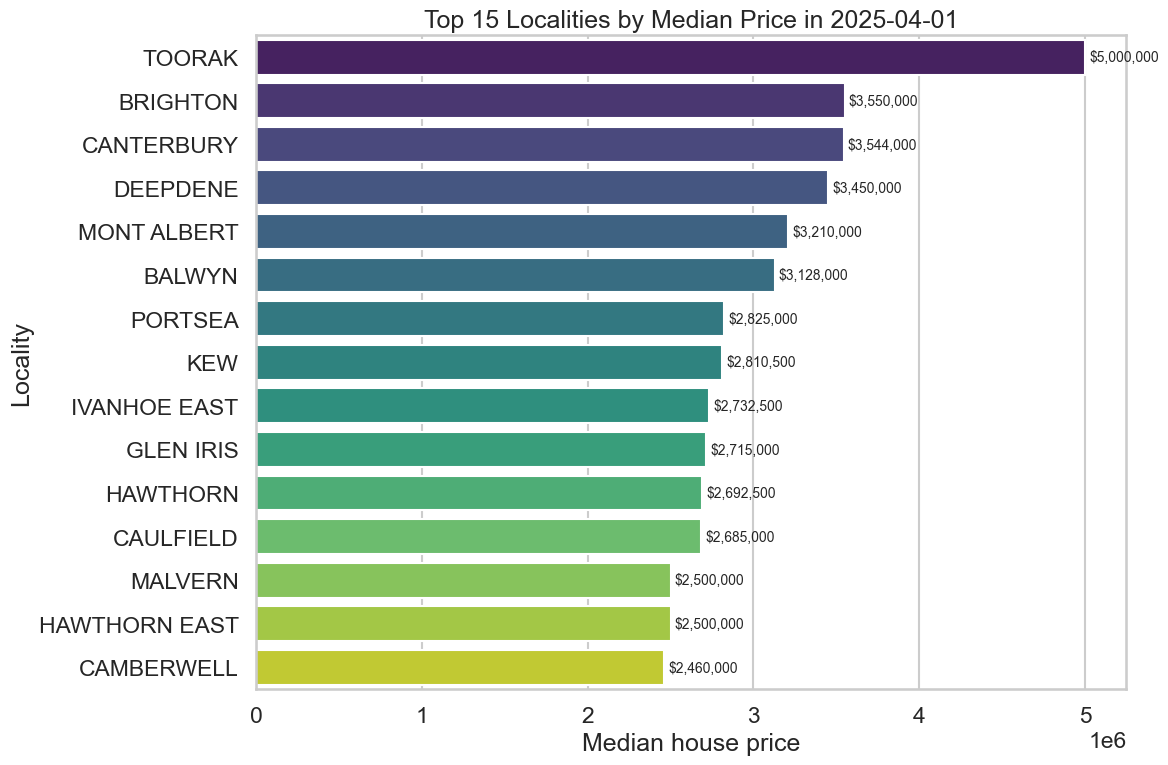

,locality,median_price
6745,TOORAK,"5,000,000.00"
927,BRIGHTON,"3,550,000.00"
1196,CANTERBURY,"3,544,000.00"
2018,DEEPDENE,"3,450,000.00"
4576,MONT ALBERT,"3,210,000.00"
429,BALWYN,"3,128,000.00"
5488,PORTSEA,"2,825,000.00"
3621,KEW,"2,810,500.00"
3378,IVANHOE EAST,"2,732,500.00"
2804,GLEN IRIS,"2,715,000.00"


In [25]:
latest_date = clean_df['date'].max()
latest_snapshot = (
    clean_df[clean_df['date'] == latest_date]
    .sort_values('median_price', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 8))
ax_latest = sns.barplot(data=latest_snapshot, y='locality', x='median_price', hue='locality', palette='viridis', legend=False)
plt.title(f'Top 15 Localities by Median Price in {latest_date.date()}')
plt.xlabel('Median house price')
plt.ylabel('Locality')
annotate_bars(ax_latest, orientation='h', formatter=lambda value: f'${value:,.0f}')
plt.tight_layout()
save_figure('latest_top_localities.png')
plt.show()

latest_snapshot[['locality', 'median_price']]


## Example Locality Trends

To make the project more readable for a portfolio audience, the next figure compares price movements for five well-observed localities.


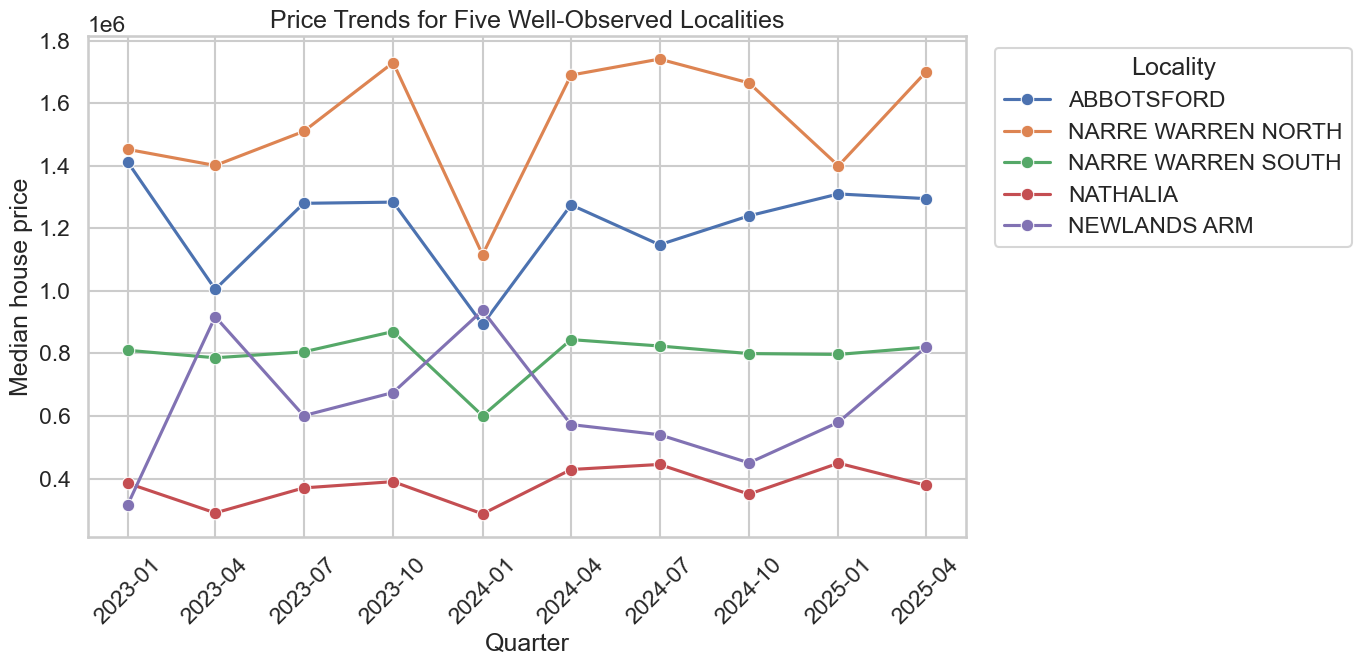

In [26]:
selected_localities = obs_per_locality.head(5).index.tolist()
selected_trends = clean_df[clean_df['locality'].isin(selected_localities)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=selected_trends, x='date', y='median_price', hue='locality', marker='o')
plt.title('Price Trends for Five Well-Observed Localities')
plt.xlabel('Quarter')
plt.ylabel('Median house price')
plt.xticks(rotation=45)
plt.legend(title='Locality', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_figure('locality_trends.png')
plt.show()


## Feature Engineering

The forecasting features are intentionally simple and interpretable. They encode locality identity and recent price history so the model can estimate the next quarterly median price.


In [27]:
def build_features(clean_df: pd.DataFrame) -> pd.DataFrame:
    # Sort records by locality and time before building lag-based features.
    df = clean_df.copy().sort_values(['locality', 'year', 'quarter'])
    by_loc = df.groupby('locality')

    # Use one-quarter and two-quarter lags plus a rolling mean to capture short-term momentum.
    df['lag_1'] = by_loc['median_price'].shift(1)
    df['lag_2'] = by_loc['median_price'].shift(2)
    df['rolling_mean_2'] = by_loc['median_price'].shift(1).rolling(2).mean().reset_index(level=0, drop=True)

    dataset_median = df['median_price'].median()
    for col in ['lag_1', 'lag_2', 'rolling_mean_2']:
        df[col] = df[col].fillna(dataset_median)

    return df


def time_split(df: pd.DataFrame, test_ratio: float = 0.2) -> tuple[pd.DataFrame, pd.DataFrame]:
    # Apply a chronological split so the model is always evaluated on future periods.
    unique_periods = (
        df[['year', 'quarter']]
        .drop_duplicates()
        .sort_values(['year', 'quarter'])
        .reset_index(drop=True)
    )

    cutoff_idx = max(1, int(len(unique_periods) * (1 - test_ratio)))
    cutoff = unique_periods.iloc[cutoff_idx - 1]

    is_train = (df['year'] < cutoff['year']) | ((df['year'] == cutoff['year']) & (df['quarter'] <= cutoff['quarter']))
    train_df = df[is_train].copy()
    test_df = df[~is_train].copy()

    if test_df.empty:
        train_df = df.iloc[:-1].copy()
        test_df = df.iloc[-1:].copy()

    return train_df, test_df


feat_df = build_features(clean_df)
train_df, test_df = time_split(feat_df)

print('Training rows:', len(train_df))
print('Testing rows:', len(test_df))
feat_df.head()


Training rows: 6048
Testing rows: 1506


,locality,year,quarter,median_price,date,lag_1,lag_2,rolling_mean_2
0,ABBOTSFORD,2023,1,"1,412,000.00",2023-01-01,"735,500.00","735,500.00","735,500.00"
1,ABBOTSFORD,2023,2,"1,005,000.00",2023-04-01,"1,412,000.00","735,500.00","735,500.00"
2,ABBOTSFORD,2023,3,"1,280,000.00",2023-07-01,"1,005,000.00","1,412,000.00","1,208,500.00"
3,ABBOTSFORD,2023,4,"1,283,800.00",2023-10-01,"1,280,000.00","1,005,000.00","1,142,500.00"
4,ABBOTSFORD,2024,1,"892,501.78",2024-01-01,"1,283,800.00","1,280,000.00","1,281,900.00"


## Model Training Setup

We benchmark both simple and nonlinear models to compare interpretability against predictive performance.


In [28]:
def evaluate(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    # Compute the main regression metrics used in the benchmark table.
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': rmse,
        'r2': float(r2_score(y_true, y_pred)),
    }


def build_preprocessor() -> ColumnTransformer:
    # Standardize numeric features and one-hot encode the locality name.
    numeric_features = ['year', 'quarter', 'lag_1', 'lag_2', 'rolling_mean_2']
    categorical_features = ['locality']

    numeric_pipeline = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, numeric_features),
            ('cat', categorical_pipeline, categorical_features),
        ]
    )


def build_models() -> tuple[dict[str, object], dict[str, str]]:
    # Define the candidate models for comparison.
    models = {
        'linear_regression': LinearRegression(),
        'random_forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
        'gradient_boosting': GradientBoostingRegressor(random_state=42),
    }
    skipped_models = {}

    if XGBRegressor is not None:
        models['xgboost'] = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective='reg:squarederror',
        )
    else:
        skipped_models['xgboost'] = 'xgboost package not installed'

    if LGBMRegressor is not None:
        models['lightgbm'] = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective='regression',
            verbosity=-1,
        )
    else:
        skipped_models['lightgbm'] = 'lightgbm package not installed'

    return models, skipped_models


def train_and_compare(dataset_dir: str | Path = DATASET_DIR, artifacts_dir: str | Path = ARTIFACTS_DIR):
    # Train all candidate models, compare them, and export the best-performing pipeline.
    artifacts_path = Path(artifacts_dir)
    artifacts_path.mkdir(parents=True, exist_ok=True)

    clean_df = load_and_clean_dataset(dataset_dir)
    feat_df = build_features(clean_df)
    feat_df.to_csv(artifacts_path / 'clean_long_data.csv', index=False)

    train_df, test_df = time_split(feat_df)
    feature_cols = ['locality', 'year', 'quarter', 'lag_1', 'lag_2', 'rolling_mean_2']
    target_col = 'median_price'

    x_train, y_train = train_df[feature_cols], train_df[target_col]
    x_test, y_test = test_df[feature_cols], test_df[target_col]

    models, skipped_models = build_models()
    metrics = {}
    trained_pipelines = {}
    predictions = {}

    for name, model in models.items():
        pipeline = Pipeline(
            steps=[
                ('preprocessor', build_preprocessor()),
                ('model', model),
            ]
        )
        pipeline.fit(x_train, y_train)
        preds = pipeline.predict(x_test)
        metrics[name] = evaluate(y_test.to_numpy(), preds)
        trained_pipelines[name] = pipeline
        predictions[name] = preds

    best_model_name = min(metrics.keys(), key=lambda model_name: metrics[model_name]['rmse'])
    best_pipeline = trained_pipelines[best_model_name]
    joblib.dump(best_pipeline, artifacts_path / 'best_model.joblib')

    latest_history = clean_df.sort_values(['locality', 'year', 'quarter']).groupby('locality', as_index=False).tail(2)
    latest_history.to_csv(artifacts_path / 'latest_history.csv', index=False)

    meta = {
        'best_model': best_model_name,
        'train_rows': int(len(train_df)),
        'test_rows': int(len(test_df)),
        'locality_count': int(clean_df['locality'].nunique()),
    }
    if skipped_models:
        meta['skipped_models'] = skipped_models

    metrics_payload = {'metrics': metrics, 'meta': meta}
    with open(artifacts_path / 'metrics.json', 'w', encoding='utf-8') as file:
        json.dump(metrics_payload, file, ensure_ascii=False, indent=2)

    return {
        'clean_df': clean_df,
        'feat_df': feat_df,
        'train_df': train_df,
        'test_df': test_df,
        'metrics': metrics,
        'meta': meta,
        'best_pipeline': best_pipeline,
        'best_model_name': best_model_name,
        'predictions': predictions,
    }


## Train and Compare Models

The benchmark below compares all available candidate models and saves the best pipeline to `artifacts/best_model.joblib`.


In [29]:
results = train_and_compare()
metrics_df = pd.DataFrame(results['metrics']).T.sort_values('rmse')
display(metrics_df)
results['meta']


,mae,rmse,r2
linear_regression,"93,477.93","155,557.10",0.92
gradient_boosting,"106,093.60","182,402.66",0.89
random_forest,"114,125.85","193,661.20",0.88
xgboost,"113,086.41","195,737.24",0.88
lightgbm,"124,020.14","229,072.94",0.83


{'best_model': 'linear_regression',
 'train_rows': 6048,
 'test_rows': 1506,
 'locality_count': 777}

## Model Comparison Visualization

All bar charts include exact values so the performance differences are easy to read in both Jupyter and GitHub.


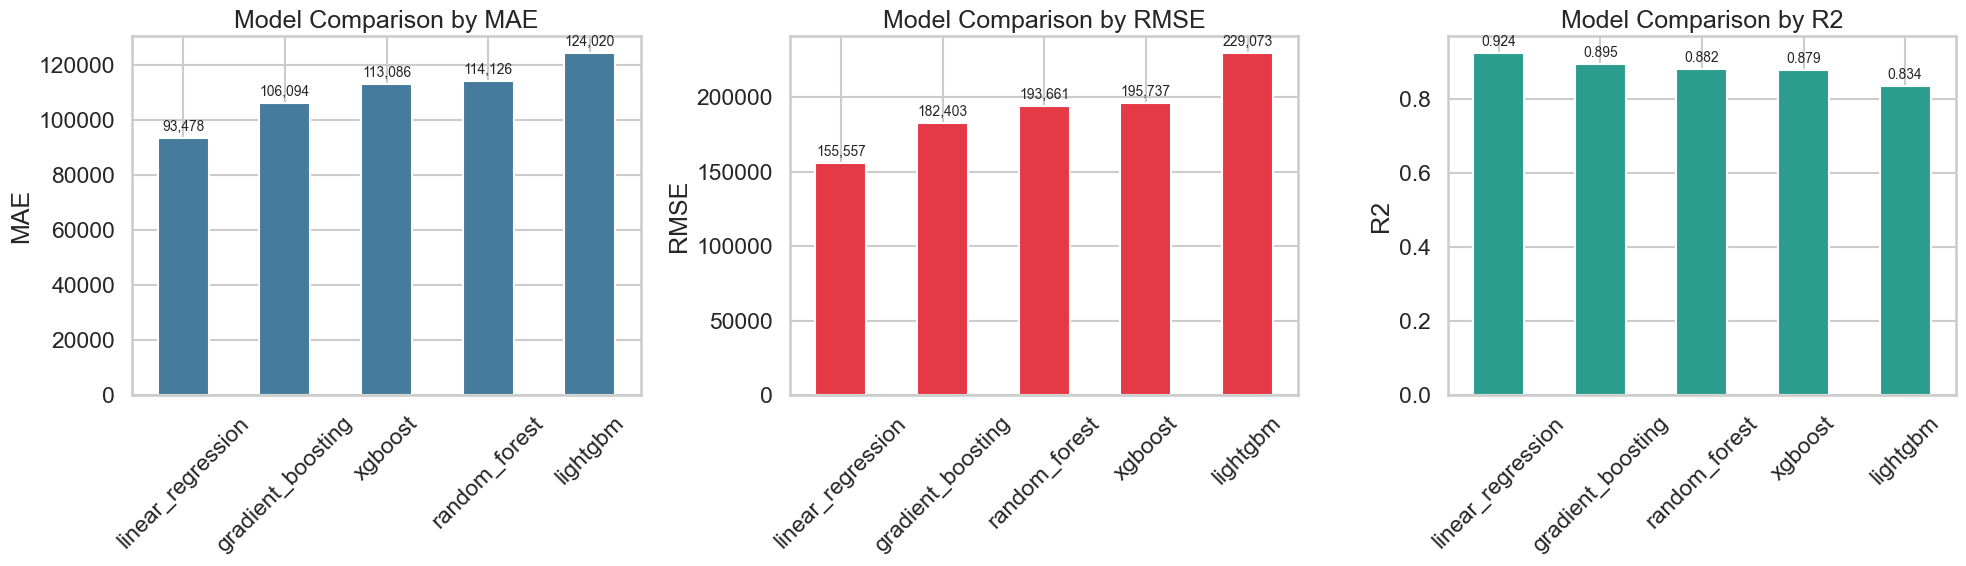

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

mae_ax = metrics_df.sort_values('mae').plot(kind='bar', y='mae', ax=axes[0], color='#457b9d', legend=False)
axes[0].set_title('Model Comparison by MAE')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)
annotate_bars(mae_ax, orientation='v', formatter=lambda value: f'{value:,.0f}')

rmse_ax = metrics_df.sort_values('rmse').plot(kind='bar', y='rmse', ax=axes[1], color='#e63946', legend=False)
axes[1].set_title('Model Comparison by RMSE')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)
annotate_bars(rmse_ax, orientation='v', formatter=lambda value: f'{value:,.0f}')

r2_ax = metrics_df.sort_values('r2', ascending=False).plot(kind='bar', y='r2', ax=axes[2], color='#2a9d8f', legend=False)
axes[2].set_title('Model Comparison by R2')
axes[2].set_ylabel('R2')
axes[2].tick_params(axis='x', rotation=45)
annotate_bars(r2_ax, orientation='v', formatter=lambda value: f'{value:.3f}')

plt.tight_layout()
save_figure('model_comparison.png')
plt.show()


## Best Model Diagnostic Plot

A scatter plot of actual versus predicted prices provides a quick diagnostic view of model fit. Points closer to the diagonal represent better prediction quality.


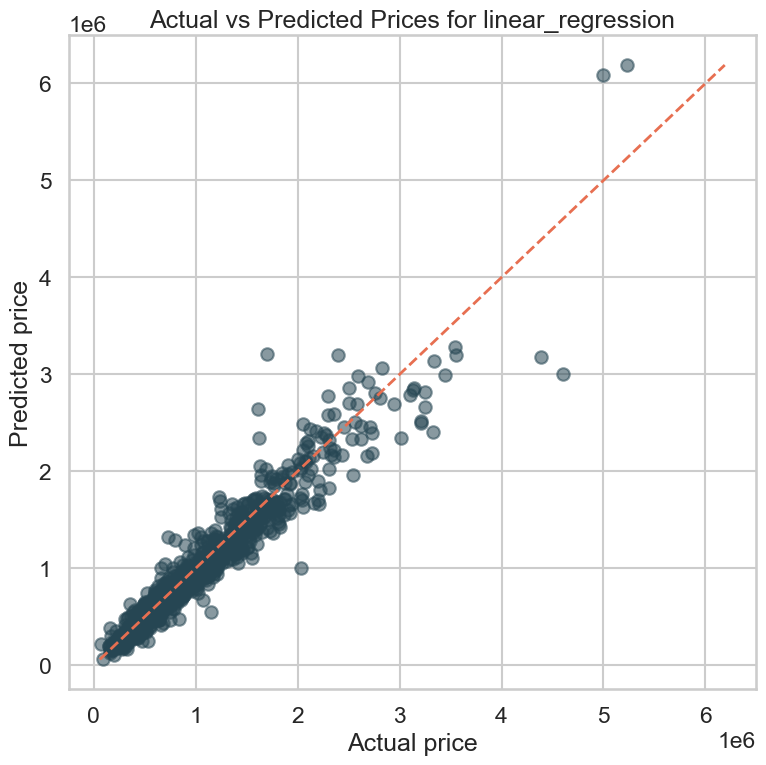

In [31]:
best_model_name = results['best_model_name']
y_test = results['test_df']['median_price'].to_numpy()
best_preds = results['predictions'][best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds, alpha=0.55, color='#264653')
line_min = min(y_test.min(), best_preds.min())
line_max = max(y_test.max(), best_preds.max())
plt.plot([line_min, line_max], [line_min, line_max], color='#e76f51', linestyle='--', linewidth=2)
plt.title(f'Actual vs Predicted Prices for {best_model_name}')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.tight_layout()
save_figure('actual_vs_predicted.png')
plt.show()


## Prediction Helper

The helper below loads the saved best model and automatically backfills lag features from the latest locality history whenever possible.


In [32]:
def default_lags(locality: str, history: pd.DataFrame) -> tuple[float | None, float | None, float | None]:
    # Recover the most recent lag-based inputs for a locality.
    loc_history = history[history['locality'].str.upper() == locality.upper()].sort_values(['year', 'quarter'])
    if loc_history.empty:
        return None, None, None

    latest_prices = loc_history['median_price'].tolist()
    lag_1 = latest_prices[-1] if len(latest_prices) >= 1 else None
    lag_2 = latest_prices[-2] if len(latest_prices) >= 2 else lag_1

    if len(latest_prices) >= 2:
        rolling_mean_2 = float((latest_prices[-1] + latest_prices[-2]) / 2)
    elif len(latest_prices) == 1:
        rolling_mean_2 = float(latest_prices[-1])
    else:
        rolling_mean_2 = None

    return lag_1, lag_2, rolling_mean_2


def predict_price(
    locality: str,
    year: int,
    quarter: int,
    lag_1: float | None = None,
    lag_2: float | None = None,
    rolling_mean_2: float | None = None,
) -> dict[str, object]:
    # Use the exported model artifact to predict a future quarterly median price.
    model = joblib.load(ARTIFACTS_DIR / 'best_model.joblib')
    history = pd.read_csv(ARTIFACTS_DIR / 'latest_history.csv')

    d_lag_1, d_lag_2, d_roll = default_lags(locality, history)
    lag_1 = lag_1 if lag_1 is not None else d_lag_1
    lag_2 = lag_2 if lag_2 is not None else d_lag_2
    rolling_mean_2 = rolling_mean_2 if rolling_mean_2 is not None else d_roll

    if lag_1 is None or lag_2 is None or rolling_mean_2 is None:
        raise ValueError('Not enough history for this locality. Please provide lag_1, lag_2, and rolling_mean_2 manually.')

    features = pd.DataFrame(
        [
            {
                'locality': locality.upper(),
                'year': year,
                'quarter': quarter,
                'lag_1': lag_1,
                'lag_2': lag_2,
                'rolling_mean_2': rolling_mean_2,
            }
        ]
    )

    prediction = float(model.predict(features)[0])
    return {
        'locality': locality.upper(),
        'year': year,
        'quarter': quarter,
        'predicted_median_price': round(prediction, 2),
    }


predict_price('ABBOTSFORD', 2026, 2)


{'locality': 'ABBOTSFORD',
 'year': 2026,
 'quarter': 2,
 'predicted_median_price': 1260616.82}

## Optional FastAPI Layer Inside the Notebook

The notebook still defines an in-notebook FastAPI app for demonstration. For actual deployment, this repository also includes a dedicated `app.py` service entrypoint.


In [33]:
if FastAPI is None:
    print('FastAPI is not installed. Skip this section or install fastapi and uvicorn.')
else:
    app = FastAPI(title='Melbourne Housing Price Predictor', version='1.0.0')

    class PredictRequest(BaseModel):
        locality: str
        year: int = Field(..., ge=2000, le=2100)
        quarter: Literal[1, 2, 3, 4]
        lag_1: float | None = Field(default=None, gt=0)
        lag_2: float | None = Field(default=None, gt=0)
        rolling_mean_2: float | None = Field(default=None, gt=0)

    @app.get('/health')
    def health() -> dict[str, str]:
        return {'status': 'ok'}

    @app.post('/predict')
    def predict(request: PredictRequest) -> dict[str, object]:
        try:
            return predict_price(
                locality=request.locality,
                year=request.year,
                quarter=request.quarter,
                lag_1=request.lag_1,
                lag_2=request.lag_2,
                rolling_mean_2=request.rolling_mean_2,
            )
        except ValueError as exc:
            raise HTTPException(status_code=400, detail=str(exc)) from exc

    print("FastAPI app is available as variable 'app'.")
    print("For production-style local serving, use the dedicated app.py file:")
    print("uvicorn app:app --host 0.0.0.0 --port 8000")


FastAPI app is available as variable 'app'.
For production-style local serving, use the dedicated app.py file:
uvicorn app:app --host 0.0.0.0 --port 8000


## Final Summary

### Key Findings

- The cleaned VPSR dataset supports quarterly forecasting across 777 Melbourne localities.
- Simple lag-based features are already strong predictors of short-term median house prices.
- In the current benchmark, `LinearRegression` produced the best overall balance of error and fit.
- Visual analysis shows meaningful heterogeneity across localities, reinforcing the value of locality-aware modeling.

### Interpretation

- Short-term housing forecasts can be surprisingly competitive even with a compact feature set.
- More complex tree-based models did not outperform the linear baseline on this version of the dataset.
- The project works well as both a reproducible analysis notebook and a small deployment case study.

### Limitations

- The feature set does not yet include interest rates, macroeconomic trends, geospatial distance, or school-zone effects.
- Quarterly suburb-level aggregates are useful for trend modeling but do not capture property-level variation.
- A longer historical window would likely improve the stability of lag-based forecasting.

### Recommended Next Steps

1. Add external spatial and socioeconomic features.
2. Use rolling or walk-forward validation for deeper time-series evaluation.
3. Compare against geographically enriched gradient boosting models.
4. Deploy the included FastAPI service to a cloud platform after committing the trained artifacts.
